<a href="https://colab.research.google.com/github/jessicaamelia17/SBP_UTS_MODEL/blob/main/SBP_BC_UTS_Jessica_Amelia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# ─── Plot style ───────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52']
CHRON_MAP_COLORS = {
    'Lion':'#F4A261', 'Bear':'#2A9D8F', 'Wolf':'#6C63FF', 'Dolphin':'#E9C46A'
}
print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [28]:
file_path = "/content/study_habits_sample.csv"
df_raw = pd.read_csv(file_path)  # ← ganti path sesuai kebutuhan

print(f"Shape awal: {df_raw.shape}")
df_raw.head()


Shape awal: (10000, 12)


,habit_id,student_id,study_hours_weekly,study_location,preferred_study_time,study_method,procrastination_level,organization_level,uses_study_aids,academic_term,academic_year,country
0,NGA_HAB_00075721,NGA_STU_00037734,5.1,Home,Afternoon,Group Study,4.0,3.0,True,Term 3,2023/2024,Nigeria
1,NGA_HAB_00080184,NGA_STU_00068308,NaN,Home,Evening,Note-taking,3.0,3.0,True,Term 3,2023/2024,Nigeria
2,NGA_HAB_00019864,NGA_STU_00043560,4.3,Home,Variable,Practice Problems,5.0,4.0,True,Term 2,2023/2024,Nigeria
3,NGA_HAB_00076699,NGA_STU_00029039,13.8,Home,Evening,Note-taking,3.0,5.0,True,Term 1,2024/2025,Nigeria
4,NGA_HAB_00092991,NGA_STU_00040175,12.3,Home,Afternoon,Note-taking,3.0,2.0,True,Term 3,2023/2024,Nigeria


In [29]:
# Info umum dataset
print("=" * 55)
print("INFORMASI UMUM DATASET")
print("=" * 55)
df_raw.info()


INFORMASI UMUM DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   habit_id               10000 non-null  object 
 1   student_id             10000 non-null  object 
 2   study_hours_weekly     9816 non-null   float64
 3   study_location         9901 non-null   object 
 4   preferred_study_time   9912 non-null   object 
 5   study_method           9906 non-null   object 
 6   procrastination_level  9801 non-null   float64
 7   organization_level     9807 non-null   float64
 8   uses_study_aids        10000 non-null  bool   
 9   academic_term          9874 non-null   object 
 10  academic_year          9903 non-null   object 
 11  country                9903 non-null   object 
dtypes: bool(1), float64(3), object(8)
memory usage: 869.3+ KB


In [30]:
# Statistik deskriptif
print("\nStatistik Deskriptif:")
df_raw.describe(include='all').T


Statistik Deskriptif:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
habit_id,10000,10000,NGA_HAB_00023894,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
student_id,10000,9517,NGA_STU_00078002,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours_weekly,9816.0,NaN,NaN,NaN,8.053535,3.997955,0.4,5.1,7.4,10.3,30.2
study_location,9901,6,Home,3951,NaN,NaN,NaN,NaN,NaN,NaN,NaN
preferred_study_time,9912,5,Evening,2964,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_method,9906,6,Note-taking,2445,NaN,NaN,NaN,NaN,NaN,NaN,NaN
procrastination_level,9801.0,NaN,NaN,NaN,3.053362,1.110759,1.0,2.0,3.0,4.0,5.0
organization_level,9807.0,NaN,NaN,NaN,3.232691,1.097203,1.0,3.0,3.0,4.0,5.0
uses_study_aids,10000,2,True,6559,NaN,NaN,NaN,NaN,NaN,NaN,NaN
academic_term,9874,3,Term 2,3387,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
# Missing values per kolom
print("Missing Values per Kolom:")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values per Kolom:
                       Missing Count  Missing %
study_hours_weekly               184       1.84
study_location                    99       0.99
preferred_study_time              88       0.88
study_method                      94       0.94
procrastination_level            199       1.99
organization_level               193       1.93
academic_term                    126       1.26
academic_year                     97       0.97
country                           97       0.97


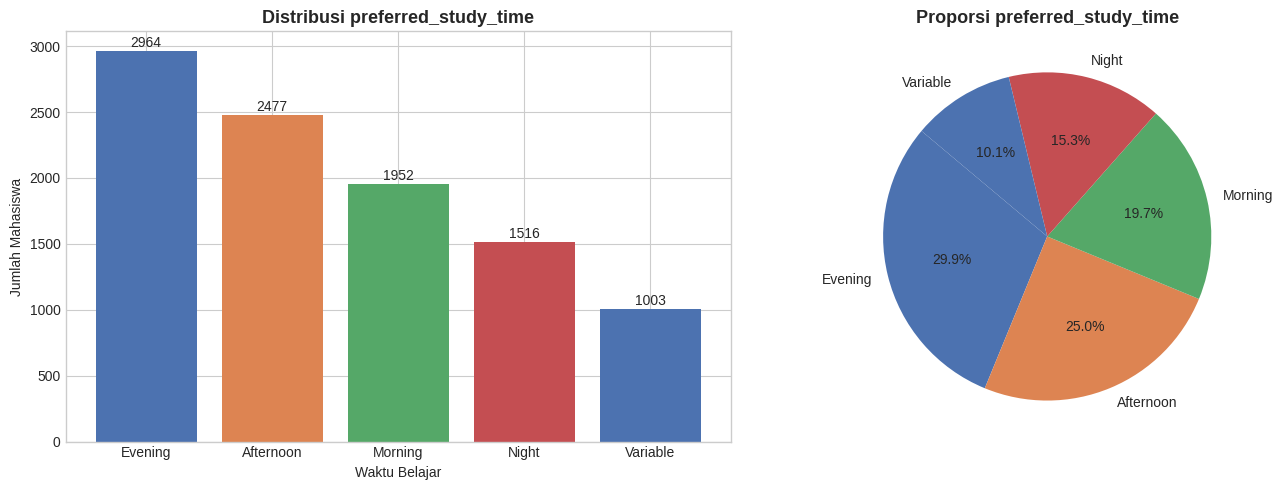


 Catatan: Kolom preferred_study_time akan menjadi DASAR pemberian label chronotype.


In [32]:
# Distribusi variabel
# target: preferred_study_time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
time_counts = df_raw['preferred_study_time'].value_counts()
axes[0].bar(time_counts.index, time_counts.values, color=COLORS[:len(time_counts)])
axes[0].set_title('Distribusi preferred_study_time', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Waktu Belajar')
axes[0].set_ylabel('Jumlah Mahasiswa')
for i, v in enumerate(time_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=10)

# Pie chart
axes[1].pie(time_counts.values, labels=time_counts.index, autopct='%1.1f%%',
            colors=COLORS[:len(time_counts)], startangle=140)
axes[1].set_title('Proporsi preferred_study_time', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print("\n Catatan: Kolom preferred_study_time akan menjadi DASAR pemberian label chronotype.")

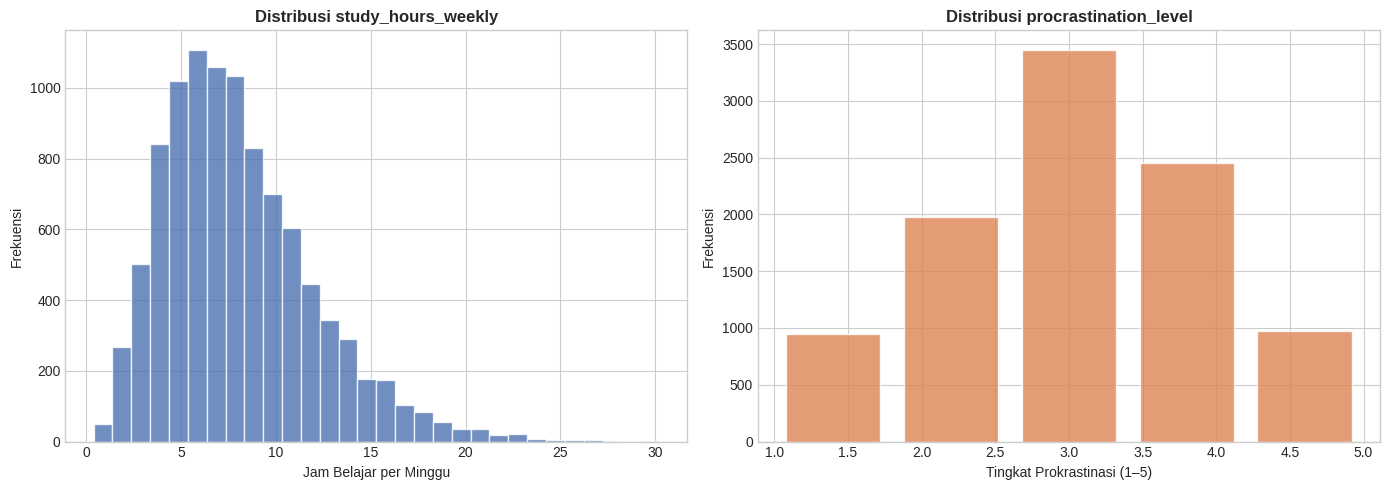

In [33]:
# Distribusi variabel numerik
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_raw['study_hours_weekly'].dropna(), bins=30, color='#4C72B0',
             edgecolor='white', alpha=0.8)
axes[0].set_title('Distribusi study_hours_weekly', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jam Belajar per Minggu')
axes[0].set_ylabel('Frekuensi')

axes[1].hist(df_raw['procrastination_level'].dropna(), bins=5, color='#DD8452',
             edgecolor='white', alpha=0.8, rwidth=0.8)
axes[1].set_title('Distribusi procrastination_level', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tingkat Prokrastinasi (1–5)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

In [8]:
#Seleksi Fitur
SELECTED_FEATURES = [
    'study_hours_weekly',   # numerik kontinu
    'study_location',       # kategorikal nominal
    'preferred_study_time', # kategorikal ordinal (juga dasar label)
    'study_method',         # kategorikal nominal
    'procrastination_level',# numerik ordinal (1–5)
    'uses_study_aids'       # boolean
]

df = df_raw[SELECTED_FEATURES].copy()

print(f"✅ Fitur dipilih: {SELECTED_FEATURES}")
print(f"✅ Shape setelah seleksi fitur: {df.shape}")
df.head(3)


✅ Fitur dipilih: ['study_hours_weekly', 'study_location', 'preferred_study_time', 'study_method', 'procrastination_level', 'uses_study_aids']
✅ Shape setelah seleksi fitur: (10000, 6)


,study_hours_weekly,study_location,preferred_study_time,study_method,procrastination_level,uses_study_aids
0,5.1,Home,Afternoon,Group Study,4.0,True
1,NaN,Home,Evening,Note-taking,3.0,True
2,4.3,Home,Variable,Practice Problems,5.0,True


In [34]:
#Data Cleaning
print("=" * 55)
print("SEBELUM CLEANING")
print("=" * 55)
print(f"Total baris: {len(df)}")
print(f"Total missing values:\n{df.isnull().sum()}\n")

# Hapus baris duplikat
n_dup = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"Baris duplikat dihapus : {n_dup}")

# Tangani missing values
#     - study_hours_weekly   → isi dengan median (robust terhadap outlier)
#     - procrastination_level→ isi dengan median
#     - study_location       → isi dengan modus
#     - preferred_study_time → HAPUS baris (krusial untuk labeling)
#     - study_method         → isi dengan modus
#     - uses_study_aids      → isi dengan modus

before = len(df)
df.dropna(subset=['preferred_study_time'], inplace=True)
print(f"Baris tanpa preferred_study_time dihapus: {before - len(df)}")

df['study_hours_weekly'].fillna(df['study_hours_weekly'].median(), inplace=True)
df['procrastination_level'].fillna(df['procrastination_level'].median(), inplace=True)
df['study_location'].fillna(df['study_location'].mode()[0], inplace=True)
df['study_method'].fillna(df['study_method'].mode()[0], inplace=True)
df['uses_study_aids'].fillna(df['uses_study_aids'].mode()[0], inplace=True)

print(f"\n✅ Missing values setelah cleaning:")
print(df.isnull().sum())

print(f"\nShape setelah cleaning: {df.shape}")


SEBELUM CLEANING
Total baris: 9379
Total missing values:
study_hours_weekly       0
study_location           0
preferred_study_time     0
study_method             0
procrastination_level    0
uses_study_aids          0
chronotype               0
dtype: int64

Baris duplikat dihapus : 106
Baris tanpa preferred_study_time dihapus: 0

✅ Missing values setelah cleaning:
study_hours_weekly       0
study_location           0
preferred_study_time     0
study_method             0
procrastination_level    0
uses_study_aids          0
chronotype               0
dtype: int64

Shape setelah cleaning: (9273, 7)


In [35]:
#Deteksi & Handling Outlier (study_hours_weekly)
# Metode: IQR (Interquartile Range)
Q1 = df['study_hours_weekly'].quantile(0.25)
Q3 = df['study_hours_weekly'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

n_outlier = ((df['study_hours_weekly'] < lower_bound) |
             (df['study_hours_weekly'] > upper_bound)).sum()

# Winsorize (cap) outlier alih-alih menghapus agar data tidak berkurang banyak
df['study_hours_weekly'] = df['study_hours_weekly'].clip(lower_bound, upper_bound)

print(f"📐 IQR Outlier Handling — study_hours_weekly")
print(f"   Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"   Batas bawah: {lower_bound:.2f} | Batas atas: {upper_bound:.2f}")
print(f"   Outlier di-cap (winsorize): {n_outlier} nilai")


📐 IQR Outlier Handling — study_hours_weekly
   Q1=5.20, Q3=10.30, IQR=5.10
   Batas bawah: -2.45 | Batas atas: 17.95
   Outlier di-cap (winsorize): 0 nilai


✅ Label Chronotype berhasil di-assign

Distribusi Chronotype:
chronotype
Wolf       4153
Bear       2302
Lion       1841
Dolphin     977
Name: count, dtype: int64


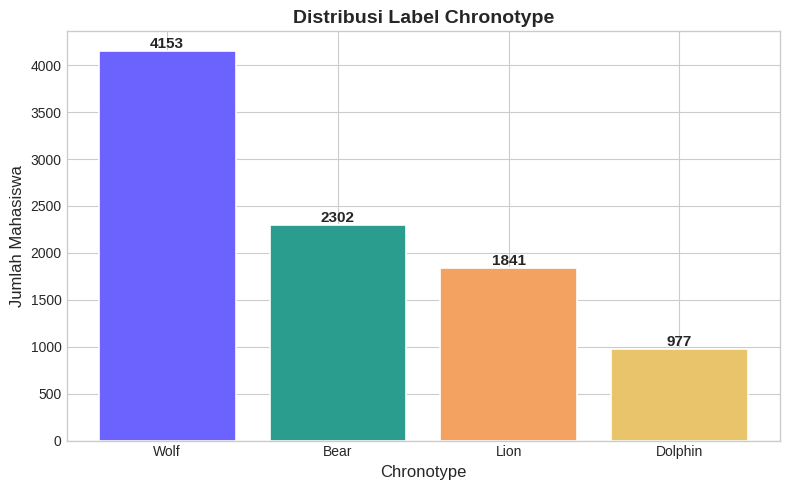


⚠️  Catatan: Wolf menggabungkan Evening+Night → kemungkinan kelas dominan.


In [36]:
# LANGKAH 4: Label Engineering — Assign CHRONOTYPE
CHRONOTYPE_MAP = {
    'Morning'  : 'Lion',
    'Afternoon': 'Bear',
    'Evening'  : 'Wolf',
    'Night'    : 'Wolf',    # night owl masuk kategori Wolf
    'Variable' : 'Dolphin'
}

df['chronotype'] = df['preferred_study_time'].map(CHRONOTYPE_MAP)

print("✅ Label Chronotype berhasil di-assign")
print("\nDistribusi Chronotype:")
ct_dist = df['chronotype'].value_counts()
print(ct_dist)

# Visualisasi distribusi label
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(ct_dist.index,
              ct_dist.values,
              color=[CHRON_MAP_COLORS[c] for c in ct_dist.index],
              edgecolor='white', linewidth=1.2)
ax.set_title('Distribusi Label Chronotype', fontsize=14, fontweight='bold')
ax.set_xlabel('Chronotype', fontsize=12)
ax.set_ylabel('Jumlah Mahasiswa', fontsize=12)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(int(bar.get_height())), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n⚠️  Catatan: Wolf menggabungkan Evening+Night → kemungkinan kelas dominan.")


In [37]:
# LANGKAH 5: Transformasi / Encoding
df_model = df.copy()

# 5a. Boolean → int
df_model['uses_study_aids'] = df_model['uses_study_aids'].astype(str).str.strip()
df_model['uses_study_aids'] = df_model['uses_study_aids'].map(
    {'True': 1, 'False': 0, '1': 1, '0': 0}).fillna(0).astype(int)

# 5b. study_hours_weekly → binning kategorik (untuk Forward/Backward Chaining & CF)
df_model['hours_bin'] = pd.cut(
    df_model['study_hours_weekly'],
    bins=[0, 5, 10, 25],
    labels=['Low', 'Medium', 'High']
)

# 5c. procrastination_level → binning
df_model['proc_bin'] = pd.cut(
    df_model['procrastination_level'],
    bins=[0, 2, 3, 5],
    labels=['Low', 'Medium', 'High']
)

# 5d. Label Encoding untuk fitur kategorik (digunakan Naive Bayes & CF)
le_loc   = LabelEncoder()
le_meth  = LabelEncoder()
le_ptime = LabelEncoder()
le_chron = LabelEncoder()
le_hbin  = LabelEncoder()
le_pbin  = LabelEncoder()

df_model['loc_enc']    = le_loc.fit_transform(df_model['study_location'])
df_model['meth_enc']   = le_meth.fit_transform(df_model['study_method'])
df_model['ptime_enc']  = le_ptime.fit_transform(df_model['preferred_study_time'])
df_model['chron_enc']  = le_chron.fit_transform(df_model['chronotype'])
df_model['hbin_enc']   = le_hbin.fit_transform(df_model['hours_bin'])
df_model['pbin_enc']   = le_pbin.fit_transform(df_model['proc_bin'])

print("✅ Encoding selesai")
print("\nMapping Chronotype:")
for i, cls in enumerate(le_chron.classes_):
    print(f"  {i} → {cls}")

print("\n📋 Preview df_model:")
df_model[['study_hours_weekly','hours_bin','procrastination_level','proc_bin',
          'study_location','study_method','uses_study_aids','preferred_study_time',
          'chronotype','chron_enc']].head()


✅ Encoding selesai

Mapping Chronotype:
  0 → Bear
  1 → Dolphin
  2 → Lion
  3 → Wolf

📋 Preview df_model:


,study_hours_weekly,hours_bin,procrastination_level,proc_bin,study_location,study_method,uses_study_aids,preferred_study_time,chronotype,chron_enc
0,5.1,Medium,4.0,High,Home,Group Study,1,Afternoon,Bear,0
1,7.5,Medium,3.0,Medium,Home,Note-taking,1,Evening,Wolf,3
2,4.3,Low,5.0,High,Home,Practice Problems,1,Variable,Dolphin,1
3,13.8,High,3.0,Medium,Home,Note-taking,1,Evening,Wolf,3
4,12.3,High,3.0,Medium,Home,Note-taking,1,Afternoon,Bear,0


In [50]:
# ════════════════════════════════════════════════════════════════
# BACKWARD CHAINING (TUNED FINAL)
# ════════════════════════════════════════════════════════════════

# ============================================================
# KNOWLEDGE BASE
# ============================================================
BACKWARD_KB = {

    # =========================
    # GOAL
    # =========================
    'Lion': {
        'conditions': ['prokrastinasi_rendah'],
        'confidence': 0.90
    },
    'Bear': {
        'conditions': ['prokrastinasi_sedang'],
        'confidence': 0.82
    },
    'Wolf': {
        'conditions': ['prokrastinasi_menengah_atas'],
        'confidence': 0.80
    },
    'Dolphin': {
        'conditions': ['prokrastinasi_tinggi'],
        'confidence': 0.85
    },

    # =========================
    # SUBGOAL (SUDAH DITUNING & NON-OVERLAP)
    # =========================
    'prokrastinasi_rendah': {
        'conditions': [
            ('procrastination_level', '<=', 2)
        ]
    },
    'prokrastinasi_sedang': {
        'conditions': [
            ('procrastination_level', 'between', (2.01, 3.2))
        ]
    },
    'prokrastinasi_menengah_atas': {
        'conditions': [
            ('procrastination_level', 'between', (3.21, 4.19))
        ]
    },
    'prokrastinasi_tinggi': {
        'conditions': [
            ('procrastination_level', '>=', 4.2)
        ]
    }
}

# ============================================================
# URUTAN HIPOTESIS (LOGIS)
# ============================================================
HYPOTHESIS_ORDER = ['Lion', 'Bear', 'Wolf', 'Dolphin']


# ============================================================
# CEK KONDISI
# ============================================================
def check_condition(value, operator, threshold):
    if operator == 'in':
        return value in threshold
    elif operator == '<=':
        return float(value) <= threshold
    elif operator == '>=':
        return float(value) >= threshold
    elif operator == '>':
        return float(value) > threshold
    elif operator == '<':
        return float(value) < threshold
    elif operator == 'between':
        lo, hi = threshold
        return lo <= float(value) <= hi
    return False


# ============================================================
# BACKWARD CHAINING (REKURSIF)
# ============================================================
def backward_chaining(goal, row_dict, verbose=False, visited=None):

    if visited is None:
        visited = set()

    if goal in visited:
        return False
    visited.add(goal)

    rule = BACKWARD_KB.get(goal)
    if not rule:
        return False

    if verbose:
        print(f"\n🔍 Cek: {goal}")

    for cond in rule['conditions']:

        if isinstance(cond, str):
            if verbose:
                print(f"   ➡ Subgoal: {cond}")

            if not backward_chaining(cond, row_dict, verbose, visited.copy()):
                return False

        else:
            feature, operator, threshold = cond
            val = row_dict.get(feature)
            result = check_condition(val, operator, threshold)

            if verbose:
                status = "✅" if result else "❌"
                print(f"   {status} {feature} {operator} {threshold} → {val}")

            if not result:
                return False

    return True


# ============================================================
# PREDIKSI
# ============================================================
def predict(row_dict, verbose=False):

    for hypothesis in HYPOTHESIS_ORDER:
        if verbose:
            print(f"\n=== UJI HIPOTESIS: {hypothesis} ===")

        if backward_chaining(hypothesis, row_dict, verbose):
            return hypothesis, BACKWARD_KB[hypothesis]['confidence']

    return 'Bear', 0.50


# ============================================================
# DEMO
# ============================================================
sample = df.iloc[0].to_dict()

print("DEMO BACKWARD CHAINING (TANPA preferred_study_time - TUNED)")
print("-" * 55)

result, conf = predict(sample, verbose=True)

print(f"\n🏆 Prediksi: {result} (confidence={conf})")
print(f"📌 Label asli: {sample['chronotype']}")

DEMO BACKWARD CHAINING (TANPA preferred_study_time - TUNED)
-------------------------------------------------------

=== UJI HIPOTESIS: Lion ===

🔍 Cek: Lion
   ➡ Subgoal: prokrastinasi_rendah

🔍 Cek: prokrastinasi_rendah
   ❌ procrastination_level <= 2 → 4.0

=== UJI HIPOTESIS: Bear ===

🔍 Cek: Bear
   ➡ Subgoal: prokrastinasi_sedang

🔍 Cek: prokrastinasi_sedang
   ❌ procrastination_level between (2.01, 3.2) → 4.0

=== UJI HIPOTESIS: Wolf ===

🔍 Cek: Wolf
   ➡ Subgoal: prokrastinasi_menengah_atas

🔍 Cek: prokrastinasi_menengah_atas
   ✅ procrastination_level between (3.21, 4.19) → 4.0

🏆 Prediksi: Wolf (confidence=0.8)
📌 Label asli: Bear


🎯 Accuracy BC: 0.27277628032345014

📊 Classification Report:
              precision    recall  f1-score   support

        Bear       0.25      0.36      0.29       461
     Dolphin       0.12      0.11      0.11       195
        Lion       0.20      0.30      0.24       368
        Wolf       0.46      0.25      0.32       831

    accuracy                           0.27      1855
   macro avg       0.26      0.26      0.24      1855
weighted avg       0.32      0.27      0.28      1855



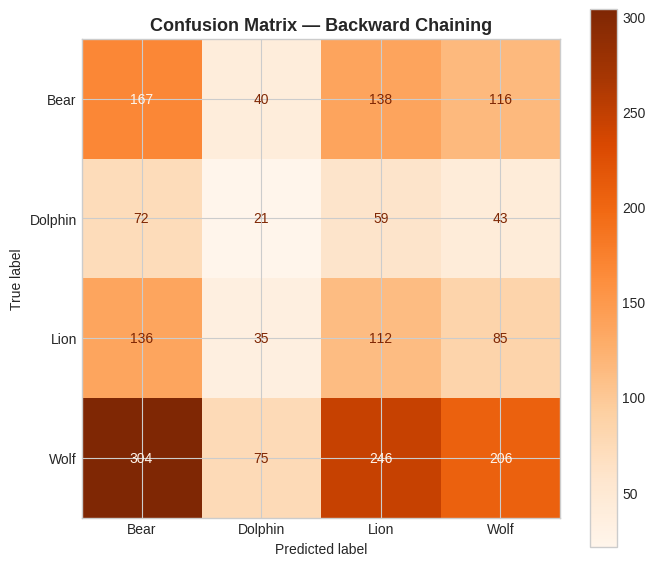


📈 Rata-rata Confidence per Chronotype:
Bear: 0.8200
Dolphin: 0.8500
Lion: 0.9000
Wolf: 0.8000


In [51]:
# ════════════════════════════════════════════════════════════════
# PART: EVALUASI BACKWARD CHAINING
# ════════════════════════════════════════════════════════════════

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# ── Split data (SAMA seperti CF) ──────────────────────────────
X = df_model.copy()
y = df_model['chronotype']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Prediksi Backward Chaining ────────────────────────────────
bc_predictions = []
bc_confidences = []

for _, row in X_test.iterrows():
    pred, conf = predict(row.to_dict())   # pakai fungsi predict kamu
    bc_predictions.append(pred)
    bc_confidences.append(conf)

# ── Evaluasi ─────────────────────────────────────────────────
print("🎯 Accuracy BC:", accuracy_score(y_test, bc_predictions))

print("\n📊 Classification Report:")
print(classification_report(y_test, bc_predictions))

# ── Confusion Matrix (Style sama CF) ──────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

classes_bc = sorted(y_test.unique())

cm_bc = confusion_matrix(
    y_test,
    bc_predictions,
    labels=classes_bc
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_bc,
    display_labels=classes_bc
).plot(ax=ax, cmap='Oranges', colorbar=True)

ax.set_title('Confusion Matrix — Backward Chaining',
             fontsize=13,
             fontweight='bold')

plt.tight_layout()
plt.show()

# ── RATA-RATA CONFIDENCE PER CHRONOTYPE ───────────────────────
bc_avg = defaultdict(list)

for pred, conf in zip(bc_predictions, bc_confidences):
    bc_avg[pred].append(conf)

print("\n📈 Rata-rata Confidence per Chronotype:")
for k in bc_avg:
    print(f"{k}: {np.mean(bc_avg[k]):.4f}")